<a href="https://colab.research.google.com/github/SHREYASHSHAURYA/ML-6th-Sem-Lab/blob/main/linear_and_multilinear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Linear and Multi-Linear Regression Implementation

This notebook demonstrates the implementation of Simple Linear Regression and Multiple Linear Regression using the Boston Housing dataset.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing # Changed from load_boston
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

### Dataset: Boston Housing

We will use the Boston Housing dataset, which is a classic dataset for regression tasks. It contains information about houses in various neighborhoods of Boston, and the goal is to predict the median value of owner-occupied homes (MEDV).

**Note:** The `load_boston` dataset is deprecated in scikit-learn v1.2 and will be removed in v1.4. For new projects, consider using `load_diabetes`, `load_linnerud`, or fetching datasets from online sources.

In [13]:
# Load the California Housing dataset
housing = fetch_california_housing()

# Create a Pandas DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target # Target variable is 'MedHouseVal' in this dataset

print("Dataset description:")
print(housing.DESCR)

Dataset description:
.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census,

In [14]:
# Display the first 5 rows of the DataFrame
print("\nFirst 5 rows of the dataset:")
display(df.head())


First 5 rows of the dataset:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Simple Linear Regression

Simple Linear Regression involves predicting a target variable based on a single independent variable. Here, we'll predict 'MEDV' (Median value of owner-occupied homes in $1000s) using 'RM' (Average number of rooms per dwelling) as the independent variable.

In [15]:
# Define the feature (X) and target (y) for Simple Linear Regression
X_slr = df[['MedInc']] # Using 'MedInc' (Median Income) as the single feature
y_slr = df['MedHouseVal'] # Target variable for California Housing

# Split the data into training and testing sets
X_train_slr, X_test_slr, y_train_slr, y_test_slr = train_test_split(
    X_slr, y_slr, test_size=0.2, random_state=42
)

print(f"Training set size: {len(X_train_slr)} samples")
print(f"Testing set size: {len(X_test_slr)} samples")

Training set size: 16512 samples
Testing set size: 4128 samples


In [16]:
# Initialize and train the Linear Regression model
slr_model = LinearRegression()
slr_model.fit(X_train_slr, y_train_slr)

# Make predictions on the test set
y_pred_slr = slr_model.predict(X_test_slr)

print(f"Intercept: {slr_model.intercept_:.2f}")
print(f"Coefficient for MedInc: {slr_model.coef_[0]:.2f}") # Updated feature name

Intercept: 0.44
Coefficient for MedInc: 0.42


In [17]:
# Evaluate the Simple Linear Regression model
mse_slr = mean_squared_error(y_test_slr, y_pred_slr)
r2_slr = r2_score(y_test_slr, y_pred_slr)

print(f"Mean Squared Error (SLR): {mse_slr:.2f}")
print(f"R-squared (SLR): {r2_slr:.2f}")

Mean Squared Error (SLR): 0.71
R-squared (SLR): 0.46


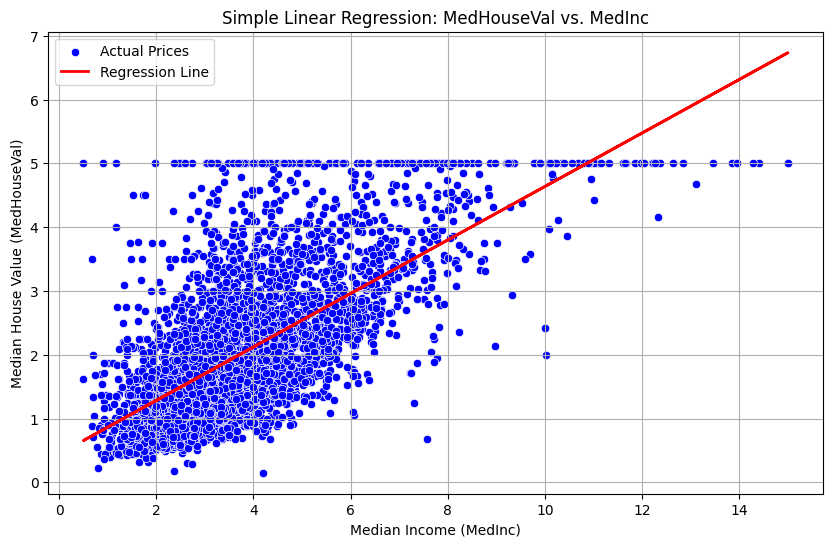

In [18]:
# Visualize the Simple Linear Regression results
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test_slr['MedInc'], y=y_test_slr, color='blue', label='Actual Prices') # Updated feature name
plt.plot(X_test_slr['MedInc'], y_pred_slr, color='red', linewidth=2, label='Regression Line') # Updated feature name
plt.title('Simple Linear Regression: MedHouseVal vs. MedInc') # Updated titles
plt.xlabel('Median Income (MedInc)') # Updated labels
plt.ylabel('Median House Value (MedHouseVal)') # Updated labels
plt.legend()
plt.grid(True)
plt.show()

### Multi-Linear Regression

Multi-Linear Regression involves predicting a target variable based on multiple independent variables. Here, we'll use several features from the California Housing dataset to predict 'MedHouseVal'.

In [19]:
# Define features (X) and target (y) for Multi-Linear Regression
X_mlr = df.drop('MedHouseVal', axis=1) # Use all features except the target
y_mlr = df['MedHouseVal'] # Target variable for California Housing

# Split the data into training and testing sets
X_train_mlr, X_test_mlr, y_train_mlr, y_test_mlr = train_test_split(
    X_mlr, y_mlr, test_size=0.2, random_state=42
)

print(f"Training set size: {len(X_train_mlr)} samples")
print(f"Testing set size: {len(X_test_mlr)} samples")

Training set size: 16512 samples
Testing set size: 4128 samples


In [20]:
# Initialize and train the Multi-Linear Regression model
mlr_model = LinearRegression()
mlr_model.fit(X_train_mlr, y_train_mlr)

# Make predictions on the test set
y_pred_mlr = mlr_model.predict(X_test_mlr)

print(f"Intercept: {mlr_model.intercept_:.2f}")
print("Coefficients:")
for feature, coef in zip(X_mlr.columns, mlr_model.coef_):
    print(f"  {feature}: {coef:.2f}")

Intercept: -37.02
Coefficients:
  MedInc: 0.45
  HouseAge: 0.01
  AveRooms: -0.12
  AveBedrms: 0.78
  Population: -0.00
  AveOccup: -0.00
  Latitude: -0.42
  Longitude: -0.43


In [21]:
# Evaluate the Multi-Linear Regression model
mse_mlr = mean_squared_error(y_test_mlr, y_pred_mlr)
r2_mlr = r2_score(y_test_mlr, y_pred_mlr)

print(f"Mean Squared Error (MLR): {mse_mlr:.2f}")
print(f"R-squared (MLR): {r2_mlr:.2f}")

Mean Squared Error (MLR): 0.56
R-squared (MLR): 0.58


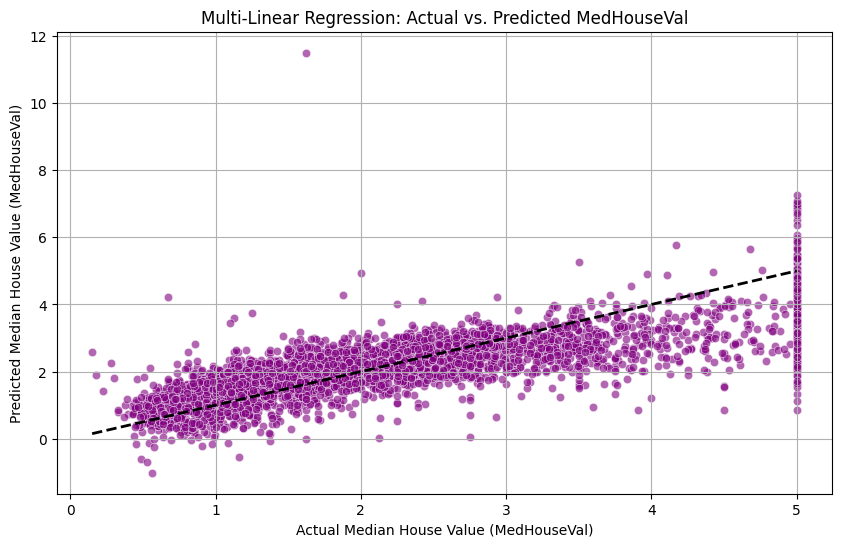

In [22]:
# Visualize the Multi-Linear Regression results (Actual vs. Predicted)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_mlr, y=y_pred_mlr, color='purple', alpha=0.6)
plt.plot([y_test_mlr.min(), y_test_mlr.max()], [y_test_mlr.min(), y_test_mlr.max()], 'k--', lw=2)
plt.title('Multi-Linear Regression: Actual vs. Predicted MedHouseVal') # Updated title
plt.xlabel('Actual Median House Value (MedHouseVal)') # Updated label
plt.ylabel('Predicted Median House Value (MedHouseVal)') # Updated label
plt.grid(True)
plt.show()